In [1]:
!pip install captum
from google.colab import files
import os

print("Please upload your kaggle.json file:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading dataset...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip
print("✅ Dataset downloaded and unzipped!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 221MB/s]

✅ Dataset downloaded and unzipped!


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Colab specific path
data_dir = '/content/chest_xray/train'
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Scrambling dataset labels...")
np.random.seed(42)
scrambled_labels = np.random.permutation(dataset.targets)
dataset.targets = scrambled_labels.tolist()

dataloader = DataLoader(dataset, batch_size=64, shuffle=True) # Increased batch size for Colab GPU

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training on randomized labels for 3 epochs...")
model.train()
for epoch in range(3):
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {running_loss/len(dataloader):.4f}")

torch.save(model.state_dict(), "resnet50_scrambled_labels.pth")
print("✅ Saved scrambled model!")

Scrambling dataset labels...
Training on randomized labels for 3 epochs...
Epoch 1 Loss: 0.2656
Epoch 2 Loss: 0.1373
Epoch 3 Loss: 0.0958
✅ Saved scrambled model!


Extracting heatmaps from the scrambled model...
✅ SUCCESS: Saved final sanity check image!


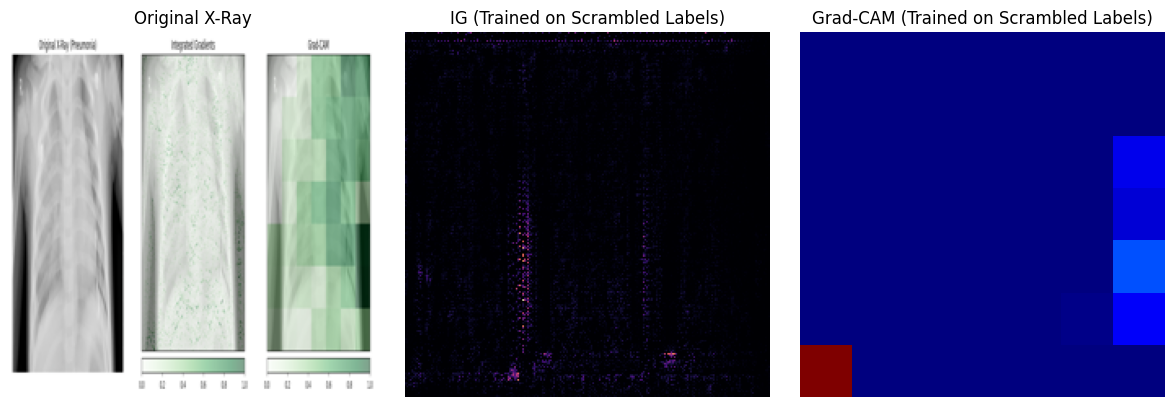

In [5]:
from captum.attr import IntegratedGradients, LayerGradCam
from PIL import Image
import matplotlib.pyplot as plt

# Load your test image
img = Image.open("/content/x ray.png").convert("RGB") # Make sure you upload x ray.png to Colab!
input_tensor = transform(img).unsqueeze(0).to(device)

model.eval()
ig = IntegratedGradients(model)
gradcam = LayerGradCam(model, model.layer4)

print("Extracting heatmaps from the scrambled model...")
ig_attr, _ = ig.attribute(input_tensor, target=1, return_convergence_delta=True)
gc_attr = gradcam.attribute(input_tensor, target=1)

def process_attr(attr):
    arr = attr.squeeze().cpu().detach().numpy()
    if arr.ndim == 3: arr = np.mean(arr, axis=0)
    arr = np.maximum(arr, 0)
    if np.max(arr) > 0: arr = arr / np.max(arr)
    return arr

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img.resize((224,224))); axes[0].set_title("Original X-Ray")
axes[1].imshow(process_attr(ig_attr), cmap='magma'); axes[1].set_title("IG (Trained on Scrambled Labels)")
axes[2].imshow(process_attr(gc_attr), cmap='jet'); axes[2].set_title("Grad-CAM (Trained on Scrambled Labels)")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig("label_randomization_check.png", bbox_inches='tight', dpi=300)
print("✅ SUCCESS: Saved final sanity check image!")